### Customer Churn & Revenue Exposure Analytics

##### 1. Import Libraries

In [37]:
# import libraries
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt

##### 2. Connect to Database

In [38]:
load_dotenv()
db_url = os.getenv("DATABASE_URL")

if db_url is None:
    print("Cant find the database URL.")
else:
    engine = create_engine(db_url)
    print("Successfully connected to the database!")



df = pd.read_sql(
    "SELECT * FROM churn_cleaned",
    engine
)

Successfully connected to the database!


##### 4. Preview Cleaned Data

In [39]:
# exploaration and cleaning done in SQL, so directly load the cleaned data into a dataframe
# see top 5 rows of the dataframe
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


##### 5. Create Tenure Segments

In [40]:
# Create tenure categories for analysis
df["tenure_segment"] = pd.cut(
    df["tenure"],
    bins=[-1,12,36,100],
    labels=[
        "New Customer",
        "Existing Customer",
        "Loyal Customer"
    ]
)

##### 6. Define Segment Analysis Function

In [41]:
def segment_risk_analysis(data, segment_column):

    result = (
        data.groupby(segment_column)
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean")
        )
        .reset_index()
    )

    # Calculate active customers and revenue
    active = (
        data[data["churn"] == "No"]
        .groupby(segment_column)
        .agg(
            active_customers=("customer_id", "count"),
            active_revenue=("monthly_charges", "sum")
        )
        .reset_index()
    )

    result = result.merge(
        active,
        on=segment_column,
        how="left"
    )

    # Convert churn rate to percenatge and round to 2 decimal places
    result["churn_rate"] = (
        result["churn_rate"] * 100
    ).round(2)

    # Estimate potential monthly revenue exposure
    result["future_revenue_exposure"] = (
        result["active_revenue"]
        *
        result["churn_rate"]
        /
        100
    )

    return result

##### 7. Analyze Customer Segments

In [42]:
# Map dimension names to DataFrame columns
dimensions = {
    "Gender": "gender",
    "Senior Citizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "Phone Service": "phone_service",
    "Multiple Lines": "multiple_lines",
    "Internet Service": "internet_service",
    "Online Security": "online_security",
    "Online Backup": "online_backup",
    "Device Protection": "device_protection",
    "Tech Support": "tech_support",
    "Streaming TV": "streaming_tv",
    "Streaming Movies": "streaming_movies",
    "Contract Type": "contract",
    "Paperless Billing": "paperless_billing",
    "Payment Behaviour": "payment_method",
    "Tenure": "tenure_segment"
}

In [43]:
all_results = []

for dimension_name, column_name in dimensions.items():

    result = segment_risk_analysis(
        df,
        column_name
    )

    result.insert(
        0,
        "dimension",
        dimension_name
    )

    result = result.rename(
        columns={
            column_name: "category"
        }
    )

    all_results.append(result)


# Combine and sort results from all dimensions
factor_analysis = pd.concat(
    all_results,
    ignore_index=True
)

factor_analysis = factor_analysis.sort_values(
    "future_revenue_exposure",
    ascending=False
).reset_index(drop=True)

print(
    factor_analysis[
        [
            "dimension",
            "category",
            "total_customers",
            "churned_customers",
            "churn_rate",
            "active_customers",
            "active_revenue",
            "future_revenue_exposure"
        ]
    ].to_string(index=False)
)

        dimension                  category  total_customers  churned_customers  churn_rate  active_customers  active_revenue  future_revenue_exposure
    Phone Service                       Yes             6361               1699       26.71              4662       294703.00             78715.171300
 Internet Service               Fiber optic             3096               1297       41.89              1799       168984.35             70787.544215
       Dependents                        No             4933               1543       31.28              3390       215148.35             67298.403880
Paperless Billing                       Yes             4171               1400       33.57              2771       197282.80             66227.835960
  Online Security                        No             3498               1461       41.77              2037       152011.60             63495.245320
   Senior Citizen                         0             5901               1393       23.61   

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3720\1107983868.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3720\1107983868.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



##### 8. Main Factor Selection

##### 8.1 Business Factor Grouping

In [44]:
# Group customer factors into business categories
factor_groups = pd.DataFrame({
    "Business Category": [
        "Contract & Lifecycle",
        "Service & Product",
        "Billing & Payment",
        "Customer Profile"
    ],
    "Factors": [
        "Contract Type, Tenure",
        "Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines",
        "Payment Behaviour, Paperless Billing",
        "Gender, Senior Citizen, Partner, Dependents"
    ]
})

factor_groups.style \
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "top"
    }) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td:first-child",
            "props": [
                ("font-weight", "bold")
            ]
        }
    ])

,Business Category,Factors
0,Contract & Lifecycle,"Contract Type, Tenure"
1,Service & Product,"Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines"
2,Billing & Payment,"Payment Behaviour, Paperless Billing"
3,Customer Profile,"Gender, Senior Citizen, Partner, Dependents"


##### 8.2 Quantitative screening
##### Which factors show meaningful differences in churn between categories?

In [45]:
dimension_summary = (
    factor_analysis
    .groupby("dimension")
    .agg(
        category_count=("category", "count"),
        lowest_churn_rate=("churn_rate", "min"),
        highest_churn_rate=("churn_rate", "max")
    )
    .reset_index()
)

# Calculate the churn rate difference within each dimension
dimension_summary["churn_spread"] = (
    dimension_summary["highest_churn_rate"]
    - dimension_summary["lowest_churn_rate"]
).round(2)

dimension_summary = (
    dimension_summary[
        [
            "dimension",
            "category_count",
            "lowest_churn_rate",
            "highest_churn_rate",
            "churn_spread"
        ]
    ]
    .sort_values(
        "churn_spread",
        ascending=False
    )
    .reset_index(drop=True)
)

print(dimension_summary.to_string(index=False))

        dimension  category_count  lowest_churn_rate  highest_churn_rate  churn_spread
    Contract Type               3               2.83               42.71         39.88
           Tenure               3              11.93               47.44         35.51
 Internet Service               3               7.40               41.89         34.49
  Online Security               3               7.40               41.77         34.37
     Tech Support               3               7.40               41.64         34.24
    Online Backup               3               7.40               39.93         32.53
Device Protection               3               7.40               39.13         31.73
Payment Behaviour               4              15.24               45.29         30.05
 Streaming Movies               3               7.40               33.68         26.28
     Streaming TV               3               7.40               33.52         26.12
   Senior Citizen               2          

In [46]:
# Select factors with a churn spread of at least 30 percentage points
candidate_factors = dimension_summary[
    dimension_summary["churn_spread"] >= 30
].copy()

candidate_factors

,dimension,category_count,lowest_churn_rate,highest_churn_rate,churn_spread
0,Contract Type,3,2.83,42.71,39.88
1,Tenure,3,11.93,47.44,35.51
2,Internet Service,3,7.40,41.89,34.49
3,Online Security,3,7.40,41.77,34.37
4,Tech Support,3,7.40,41.64,34.24
5,Online Backup,3,7.40,39.93,32.53
6,Device Protection,3,7.40,39.13,31.73
7,Payment Behaviour,4,15.24,45.29,30.05


##### 8.3 Revenue Exposure Screening
##### Which candidate factors have the highest potential revenue exposure?

In [47]:
# Review the highest revenue exposure category for each candidate factor
financial_review = (
    factor_analysis[
        factor_analysis["dimension"].isin(
            candidate_factors["dimension"]
        )
    ]
    .sort_values(
        ["dimension", "future_revenue_exposure"],
        ascending=[True, False]
    )
    .groupby("dimension")
    .first()
    .reset_index()
)

financial_review[
    [
        "dimension",
        "category",
        "total_customers",
        "churn_rate",
        "active_revenue",
        "future_revenue_exposure"
    ]
]

,dimension,category,total_customers,churn_rate,active_revenue,future_revenue_exposure
0,Contract Type,Month-to-month,3875,42.71,136447.05,58276.535055
1,Device Protection,No,3095,39.13,129758.00,50774.305400
2,Internet Service,Fiber optic,3096,41.89,168984.35,70787.544215
3,Online Backup,No,3088,39.93,130270.70,52017.090510
4,Online Security,No,3498,41.77,152011.60,63495.245320
5,Payment Behaviour,Electronic check,2365,45.29,96056.25,43503.875625
6,Tech Support,No,3473,41.64,148329.75,61764.507900
7,Tenure,New Customer,2186,47.44,53675.50,25463.657200


##### 8.4 Main Factor Selection Flow
<div align="center" style="font-size: 14px;">

CHURN GAP

Rank all factors by highest − lowest category churn

Contract Type, Tenure, Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Payment Behaviour

↓

REVENUE EXPOSURE CHECK


Keep factors with a financially material category

Contract Type, Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Payment Behaviour
Tenure is lower and kept as supporting

↓

ONE FACTOR PER BUSINESS AREA

Contract/Retention → Contract Type
Product/Service → Internet Service
Billing/Payments → Payment Behaviour

↓

MAIN 3 FACTORS

Contract Type · Internet Service · Payment Behaviour

</div>

##### 9. Main Factor Analysis (Contract Type / Internet Service / Payment Behaviour)

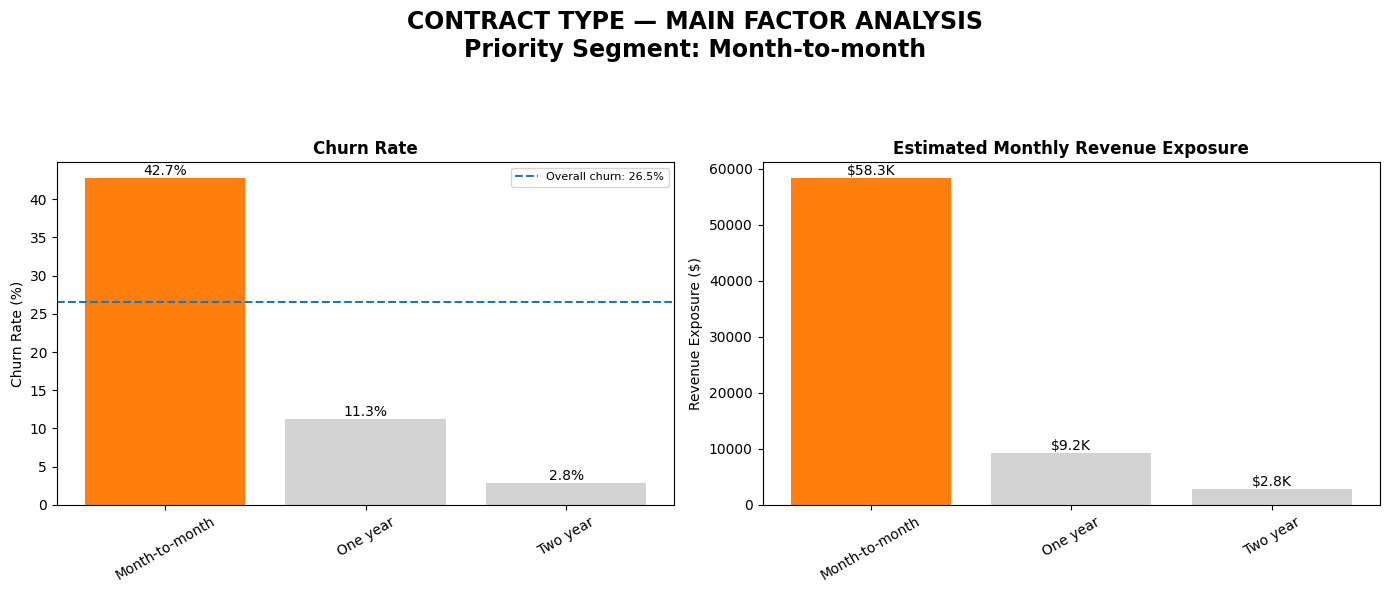

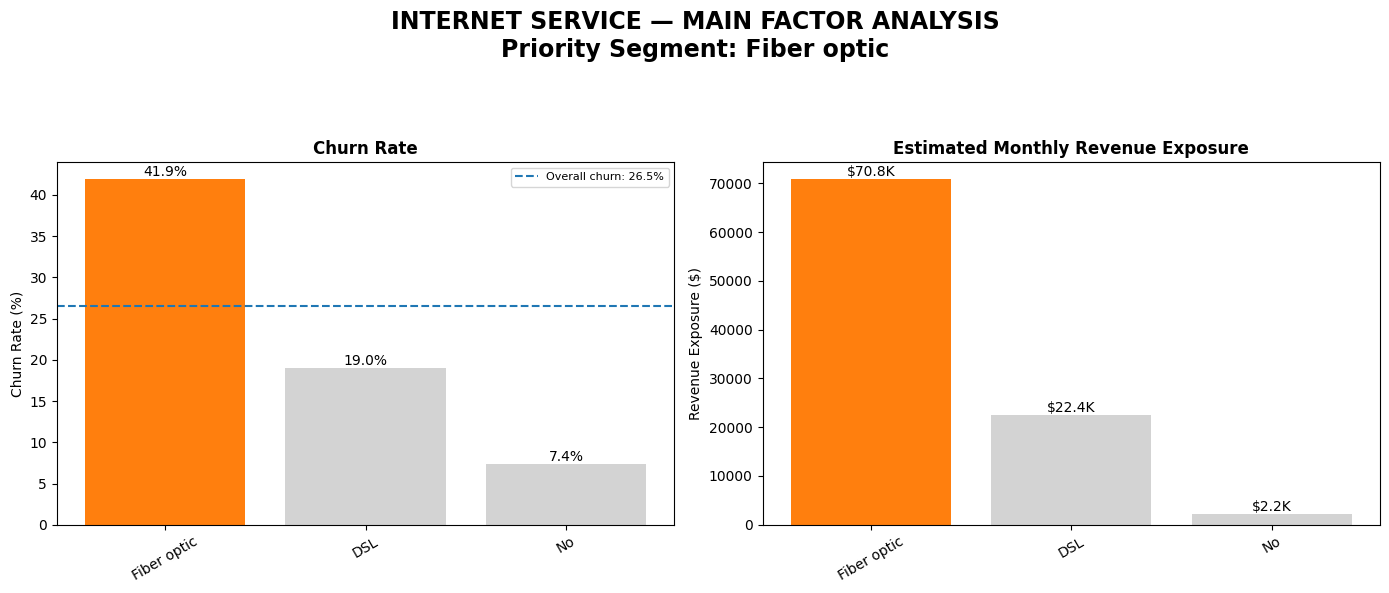

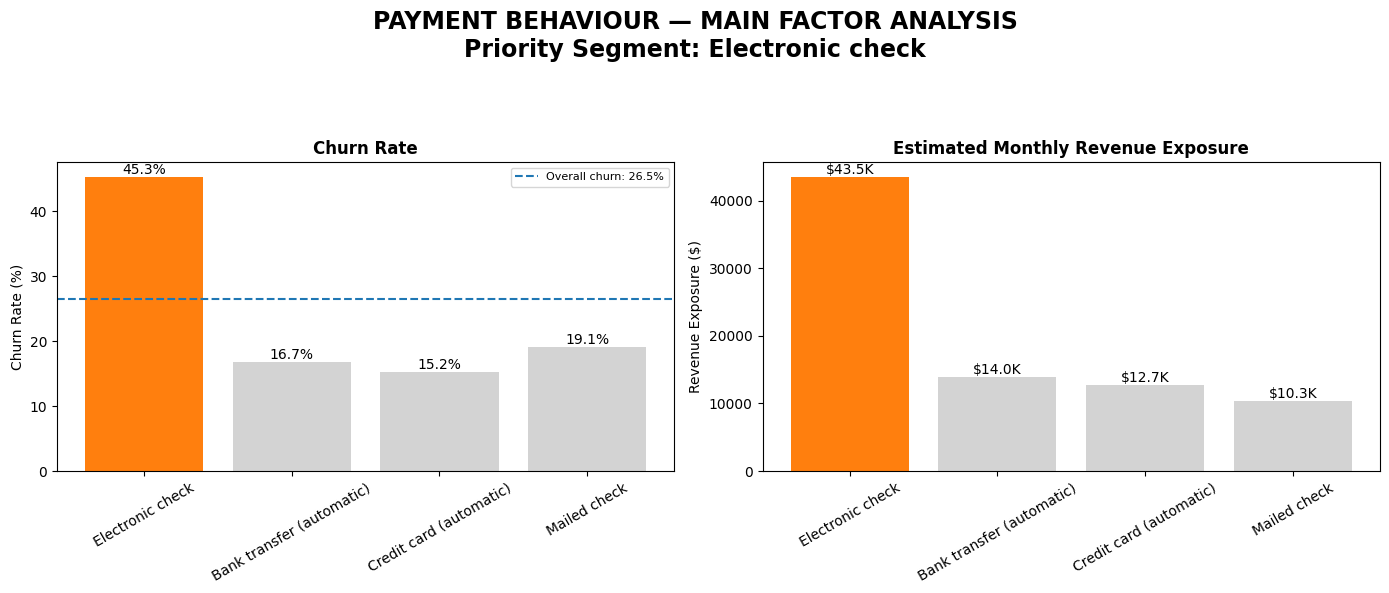

In [48]:
main_factors = [
    ("Contract Type", "contract"),
    ("Internet Service", "internet_service"),
    ("Payment Behaviour", "payment_method")
]

OVERALL_CHURN = 26.5


for factor_name, factor_col in main_factors:

    # Analyze the selected factor
    data = segment_risk_analysis(
        df,
        factor_col
    ).copy()

    # Select the category with the highest potential revenue exposure
    priority_category = data.loc[
        data["future_revenue_exposure"].idxmax(),
        factor_col
    ]

    data = data.sort_values(
        "future_revenue_exposure",
        ascending=False
    ).reset_index(drop=True)

    categories = data[
        factor_col
    ].astype(str)

    # Highlight the priority category
    bar_colors = [
        "tab:orange"
        if category == str(priority_category)
        else "lightgray"
        for category in categories
    ]

    # Create churn and revenue exposure charts
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    # Churn rate
    ax = axes[0]

    bars = ax.bar(
        categories,
        data["churn_rate"],
        color=bar_colors
    )

    ax.axhline(
        OVERALL_CHURN,
        linestyle="--",
        linewidth=1.5,
        label=f"Overall churn: {OVERALL_CHURN:.1f}%"
    )

    ax.set_title(
        "Churn Rate",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Churn Rate (%)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["churn_rate"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.legend(fontsize=8)

    # Revenue exposure
    ax = axes[1]

    bars = ax.bar(
        categories,
        data["future_revenue_exposure"],
        color=bar_colors
    )

    ax.set_title(
        "Estimated Monthly Revenue Exposure",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Revenue Exposure ($)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["future_revenue_exposure"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"${value / 1000:.1f}K",
            ha="center",
            va="bottom"
        )


    # Add the factor and priority segment to the chart title
    fig.suptitle(
        f"{factor_name.upper()} — MAIN FACTOR ANALYSIS\n"
        f"Priority Segment: {priority_category}",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    plt.show()

#### Conclusion

Analyzed 7,043 customer records using SQL and Python, identifying a 26.5% churn rate and estimating potential future revenue exposure among active customers based on historical churn behaviour.

Segmented active customers by contract type, tenure, and payment behaviour to identify future revenue risk segments, revealing Month-to-month customers as the highest-priority group with a 42.71% churn rate, 2,220 active customers, and $58K+ projected revenue exposure.

Examined risk drivers within the Month-to-month segment, identifying customers without Tech Support ($93K+ projected revenue exposure, 1,330 customers), without Online Security ($91K+ projected revenue exposure, 1,288 customers), and Fiber Optic Internet users ($84K+ projected revenue exposure, 966 customers) as the highest-priority retention groups.

Prioritized retention opportunities by ranking risk factors based on projected revenue exposure, highlighting Month-to-month customers with service gaps as key targets for reducing potential customer attrition.